# Analyze LoRA Training Runs

This notebook summarizes and compares runs in `lora_training_runs/`.


In [1]:
from pathlib import Path
import json
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

plt.style.use("seaborn-v0_8")

In [2]:
# ---- Settings ----
RUNS_DIR = Path("./lora_training_runs")
SELECT_RUNS = None  # e.g., ["run_id_1", "run_id_2"] or None for all
SMOOTHING_WINDOW = 50  # perf-log EMA window
MAX_RUNS_IN_COMBINED_PLOT = 12  # avoid too-busy plots

RUNS_DIR.exists(), RUNS_DIR

(True, PosixPath('lora_training_runs'))

In [3]:
def _safe_json(path: Path):
    try:
        return json.loads(path.read_text())
    except Exception:
        return None


def load_run(run_dir: Path):
    cfg = _safe_json(run_dir / "run_config.json") or {}
    history = _safe_json(run_dir / "training_history.json") or {}

    perf_path = run_dir / "perf_log.jsonl"
    perf_df = None
    if perf_path.exists():
        rows = []
        with perf_path.open("r") as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                try:
                    rows.append(json.loads(line))
                except Exception:
                    continue
        if rows:
            perf_df = pd.DataFrame(rows)

    return {
        "run_id": run_dir.name,
        "run_dir": run_dir,
        "config": cfg,
        "history": history,
        "perf": perf_df,
    }


def collect_runs(runs_dir: Path, select=None):
    runs = {}
    for run_dir in runs_dir.iterdir():
        if not run_dir.is_dir():
            continue
        if select and run_dir.name not in set(select):
            continue
        data = load_run(run_dir)
        if data["history"].get("epochs"):
            runs[run_dir.name] = data
    return runs


def best_epoch_row(epochs):
    best = None
    best_loss = None
    for e in epochs:
        loss = e.get("val_loss") if e.get("val_loss") is not None else e.get("train_loss")
        if loss is None:
            continue
        if best_loss is None or loss < best_loss:
            best_loss = loss
            best = e
    return best, best_loss


def effective_batch_size(cfg):
    bs = cfg.get("batch_size")
    ga = cfg.get("gradient_accumulation_steps", 1)
    if bs is None:
        return None
    return bs * ga


def ema(series, window=50):
    if series is None or len(series) == 0:
        return series
    alpha = 2 / (window + 1)
    out = []
    ema_val = None
    for v in series:
        if ema_val is None:
            ema_val = v
        else:
            ema_val = alpha * v + (1 - alpha) * ema_val
        out.append(ema_val)
    return out


In [4]:
runs = collect_runs(RUNS_DIR, SELECT_RUNS)
print(f"Loaded runs: {len(runs)}")
list(runs.keys())

Loaded runs: 24


['719699_run_20260127-165528',
 '568acc_run_20260127-180929',
 'ed3b0a_run_20260127-183448',
 '5bacc8_run_20260127-223239',
 '9094ee_run_20260127-193718',
 'f4deab_run_20260127-182211',
 '359e90_run_20260127-213833',
 '72074b_run_20260127-220723',
 '8b95ca_run_20260127-184725',
 '1569a7_run_20260127-201549',
 'cba9f3_run_20260127-192455',
 '8b3859_run_20260127-185956',
 '9aa65b_run_20260127-164145',
 '2a13f5_run_20260127-162811',
 '3f8cf9_run_20260127-191225',
 '4c0886_run_20260127-173953',
 '216067_run_20260127-172343',
 '1aebb6_run_20260127-175513',
 'faa474_run_20260127-211407',
 'f57804_run_20260127-200258',
 'b1d768_run_20260127-161521',
 'd4d4b7_run_20260127-204524',
 '4c8f91_run_20260127-194940',
 '0ace58_run_20260127-170919']

In [5]:
# ---- Summary table ----
summary_rows = []
for run_id, data in runs.items():
    epochs = data["history"].get("epochs", [])
    if not epochs:
        continue
    best, best_loss = best_epoch_row(epochs)
    last = epochs[-1]
    cfg = data["config"]
    summary_rows.append({
        "run_id": run_id,
        "epochs": len(epochs),
        "best_epoch": best.get("epoch") if best else None,
        "best_val_loss": best.get("val_loss") if best else None,
        "best_train_loss": best.get("train_loss") if best else None,
        "last_train_loss": last.get("train_loss"),
        "last_val_loss": last.get("val_loss"),
        "train_val_gap": (last.get("val_loss") - last.get("train_loss")) if last.get("val_loss") is not None else None,
        "learning_rate": cfg.get("learning_rate"),
        "lora_r": cfg.get("lora_r"),
        "lora_alpha": cfg.get("lora_alpha"),
        "lora_dropout": cfg.get("lora_dropout"),
        "grad_accum": cfg.get("gradient_accumulation_steps"),
        "batch_size": cfg.get("batch_size"),
        "effective_batch": effective_batch_size(cfg),
        "train_subset_ratio": cfg.get("train_subset_ratio"),
        "valid_subset_ratio": cfg.get("valid_subset_ratio"),
    })

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.sort_values(by=["best_val_loss", "best_train_loss"], na_position="last")
summary_df

,run_id,epochs,best_epoch,best_val_loss,best_train_loss,last_train_loss,last_val_loss,train_val_gap,learning_rate,lora_r,lora_alpha,lora_dropout,grad_accum,batch_size,effective_batch,train_subset_ratio,valid_subset_ratio
1,568acc_run_20260127-180929,5,3,0.110794,0.164923,0.141580,0.156849,0.015269,0.00002,32,32,0.05,4,5,20,None,None
23,0ace58_run_20260127-170919,5,5,0.111201,0.145113,0.145113,0.111201,-0.033912,0.00004,16,16,0.05,4,5,20,None,None
3,5bacc8_run_20260127-223239,10,5,0.118597,0.167162,0.138987,0.157670,0.018683,0.00002,64,32,0.05,4,5,20,None,None
13,2a13f5_run_20260127-162811,5,1,0.118741,0.140229,0.157116,0.144634,-0.012482,0.00001,16,16,0.10,4,5,20,None,None
7,72074b_run_20260127-220723,10,2,0.120295,0.146096,0.160681,0.167075,0.006393,0.00002,64,32,0.00,4,5,20,None,None
19,f57804_run_20260127-200258,3,2,0.120797,0.158293,0.143925,0.166911,0.022985,0.00004,64,64,0.10,4,5,20,None,None
4,9094ee_run_20260127-193718,5,3,0.121397,0.151742,0.169949,0.161704,-0.008246,0.00002,64,64,0.10,4,5,20,None,None
22,4c8f91_run_20260127-194940,5,4,0.121739,0.134831,0.144047,0.152966,0.008919,0.00004,64,64,0.05,4,5,20,None,None
2,ed3b0a_run_20260127-183448,5,3,0.123026,0.146742,0.128910,0.182534,0.053624,0.00004,32,32,0.05,4,5,20,None,None
15,4c0886_run_20260127-173953,5,1,0.125938,0.164662,0.154506,0.140577,-0.013929,0.00001,32,32,0.05,4,5,20,None,None


## Loss curves (train vs val)

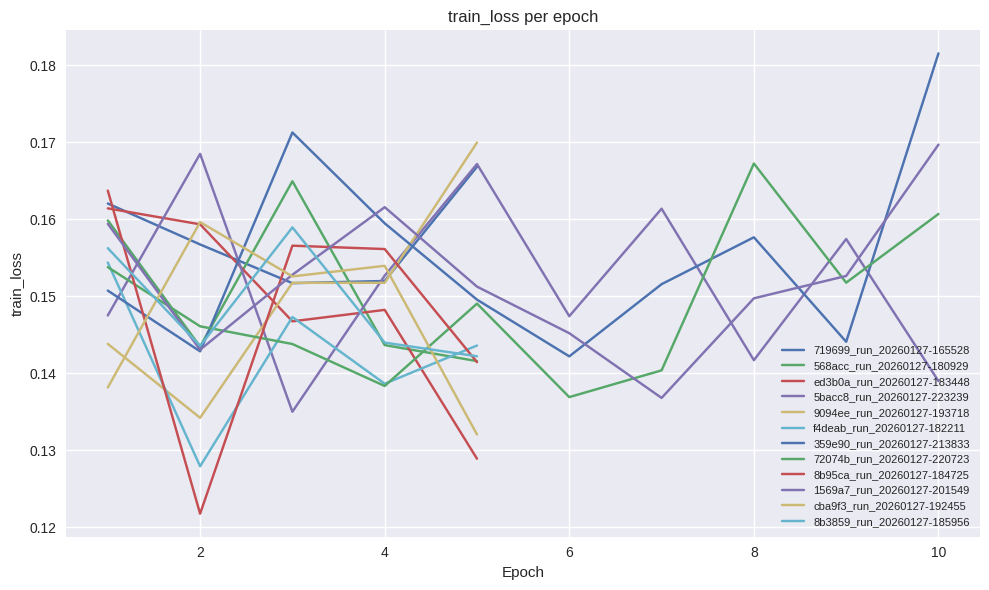

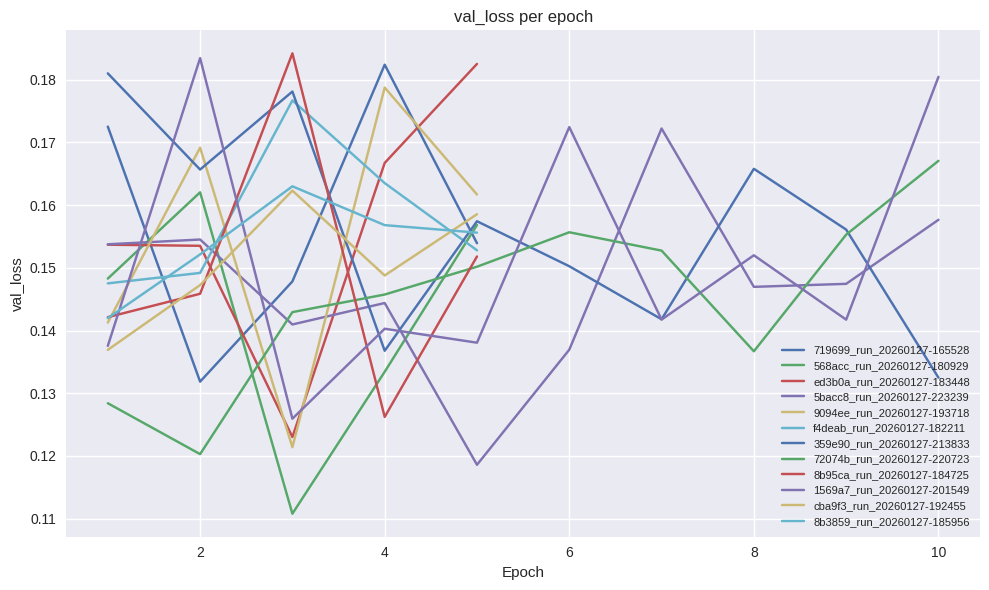

In [6]:
def plot_loss_curves(runs_dict, metric="val_loss", max_runs=12):
    plt.figure(figsize=(10, 6))
    for i, (run_id, data) in enumerate(runs_dict.items()):
        if i >= max_runs:
            break
        epochs = data["history"].get("epochs", [])
        series = [e.get(metric) for e in epochs]
        if all(v is None for v in series):
            continue
        series = [v if v is not None else np.nan for v in series]
        plt.plot(range(1, len(series) + 1), series, label=run_id)
    plt.title(f"{metric} per epoch")
    plt.xlabel("Epoch")
    plt.ylabel(metric)
    plt.legend(fontsize=8)
    plt.tight_layout()

plot_loss_curves(runs, metric="train_loss", max_runs=MAX_RUNS_IN_COMBINED_PLOT)
plot_loss_curves(runs, metric="val_loss", max_runs=MAX_RUNS_IN_COMBINED_PLOT)


## Train vs val loss gap

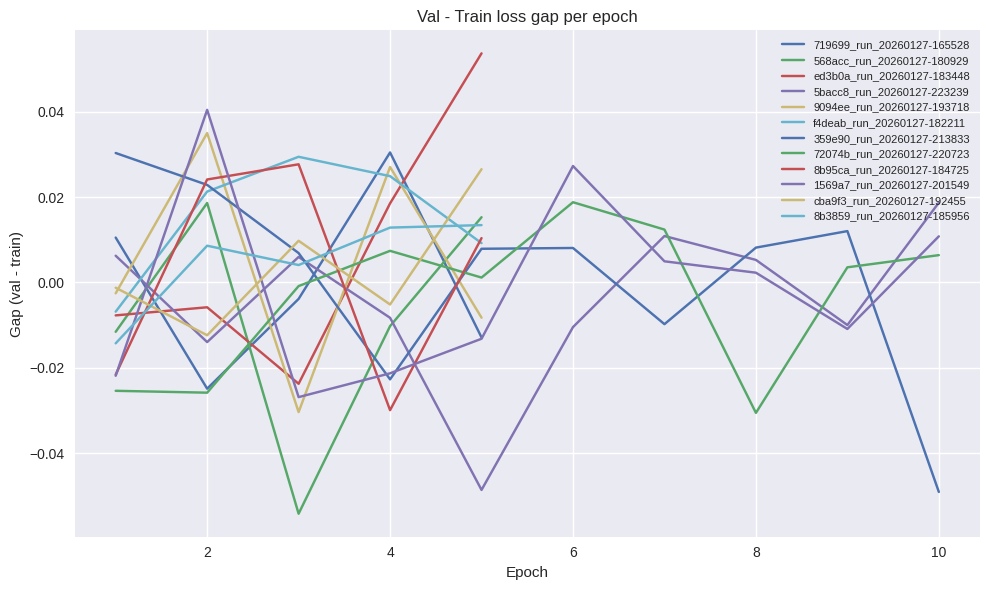

In [7]:
plt.figure(figsize=(10, 6))
for i, (run_id, data) in enumerate(runs.items()):
    if i >= MAX_RUNS_IN_COMBINED_PLOT:
        break
    epochs = data["history"].get("epochs", [])
    gaps = []
    for e in epochs:
        if e.get("val_loss") is None or e.get("train_loss") is None:
            gaps.append(np.nan)
        else:
            gaps.append(e["val_loss"] - e["train_loss"])
    if gaps:
        plt.plot(range(1, len(gaps) + 1), gaps, label=run_id)
plt.title("Val - Train loss gap per epoch")
plt.xlabel("Epoch")
plt.ylabel("Gap (val - train)")
plt.legend(fontsize=8)
plt.tight_layout()


## LR vs loss (per step, from perf_log.jsonl)

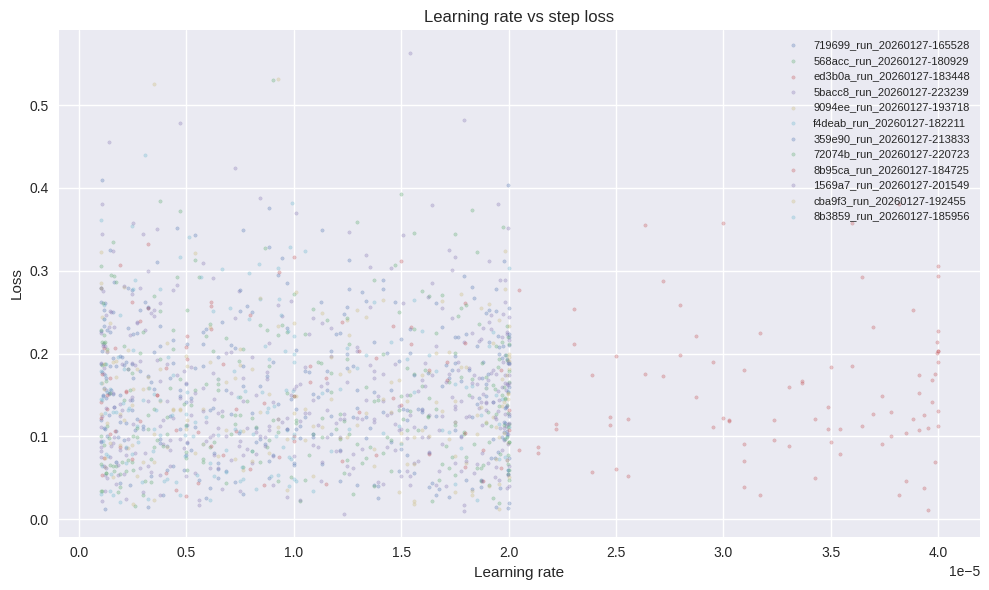

In [8]:
plt.figure(figsize=(10, 6))
plotted = 0
for run_id, data in runs.items():
    perf = data["perf"]
    if perf is None or perf.empty:
        continue
    if "learning_rate" not in perf.columns or "loss" not in perf.columns:
        continue
    plt.scatter(perf["learning_rate"], perf["loss"], s=6, alpha=0.3, label=run_id)
    plotted += 1
    if plotted >= MAX_RUNS_IN_COMBINED_PLOT:
        break
    
plt.title("Learning rate vs step loss")
plt.xlabel("Learning rate")
plt.ylabel("Loss")
plt.legend(fontsize=8)
plt.tight_layout()

## Loss trend (EMA)

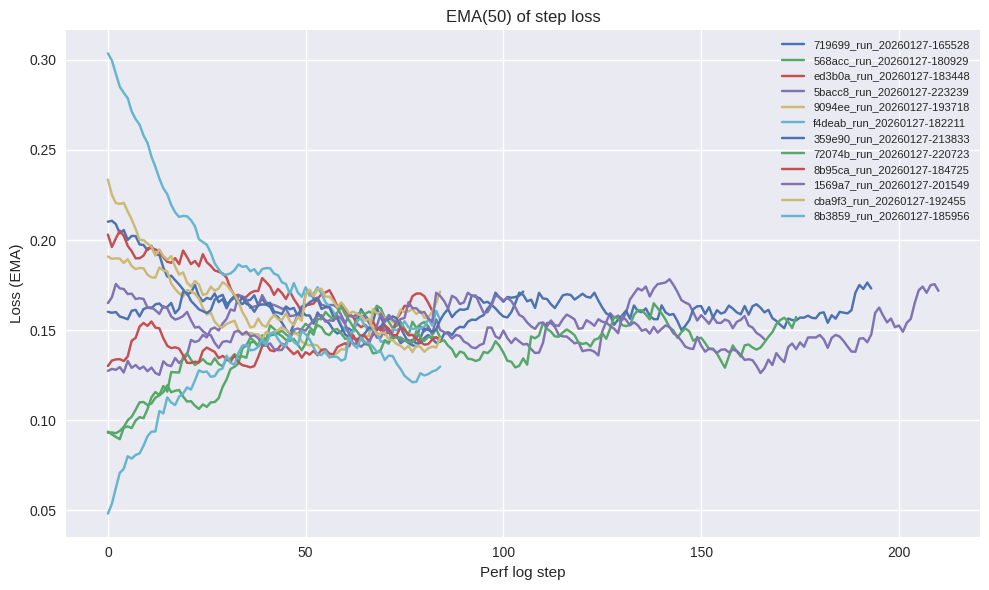

In [9]:
plt.figure(figsize=(10, 6))
plotted = 0
for run_id, data in runs.items():
    perf = data["perf"]
    if perf is None or perf.empty or "loss" not in perf.columns:
        continue
    losses = perf["loss"].tolist()
    ema_losses = ema(losses, window=SMOOTHING_WINDOW)
    plt.plot(ema_losses, label=run_id)
    plotted += 1
    if plotted >= MAX_RUNS_IN_COMBINED_PLOT:
        break
plt.title(f"EMA({SMOOTHING_WINDOW}) of step loss")
plt.xlabel("Perf log step")
plt.ylabel("Loss (EMA)")
plt.legend(fontsize=8)
plt.tight_layout()


## Gradient norms

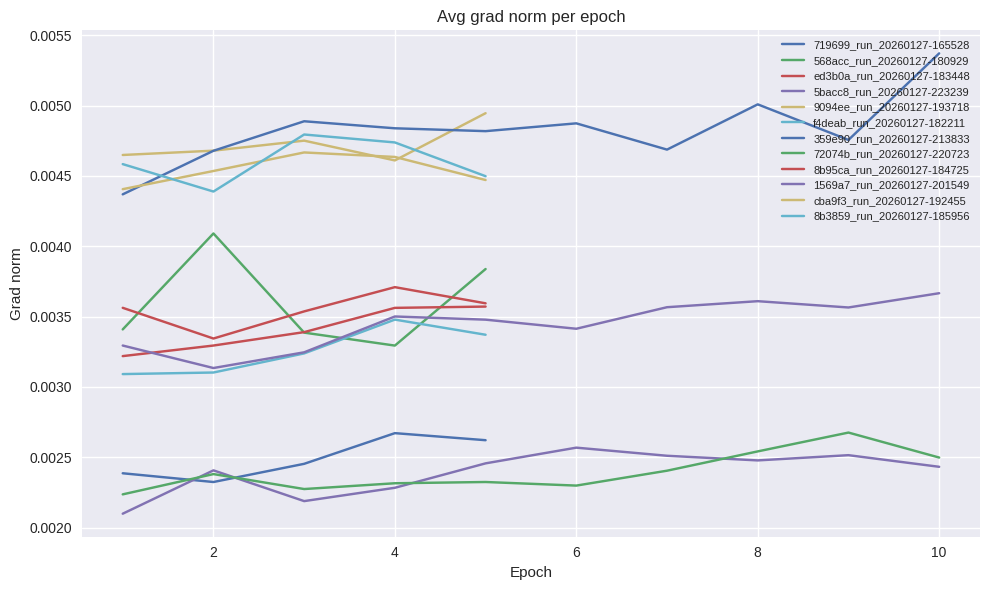

In [10]:
plt.figure(figsize=(10, 6))
plotted = 0
for run_id, data in runs.items():
    epochs = data["history"].get("epochs", [])
    if not epochs or "avg_grad_norm" not in epochs[0]:
        continue
    avg_gn = [e.get("avg_grad_norm") for e in epochs]
    if all(v is None for v in avg_gn):
        continue
    plt.plot(range(1, len(avg_gn) + 1), avg_gn, label=run_id)
    plotted += 1
    if plotted >= MAX_RUNS_IN_COMBINED_PLOT:
        break
plt.title("Avg grad norm per epoch")
plt.xlabel("Epoch")
plt.ylabel("Grad norm")
plt.legend(fontsize=8)
plt.tight_layout()

## NaN/Inf checks

In [11]:
nan_rows = []
for run_id, data in runs.items():
    perf = data["perf"]
    if perf is None or perf.empty or "loss" not in perf.columns:
        continue
    loss_series = perf["loss"]
    nan_count = int(loss_series.isna().sum())
    inf_count = int(np.isinf(loss_series).sum())
    nan_rows.append({"run_id": run_id, "nan_loss": nan_count, "inf_loss": inf_count})

pd.DataFrame(nan_rows).sort_values(["nan_loss", "inf_loss"], ascending=False)


,run_id,nan_loss,inf_loss
0,719699_run_20260127-165528,0,0
1,568acc_run_20260127-180929,0,0
2,ed3b0a_run_20260127-183448,0,0
3,5bacc8_run_20260127-223239,0,0
4,9094ee_run_20260127-193718,0,0
5,f4deab_run_20260127-182211,0,0
6,359e90_run_20260127-213833,0,0
7,72074b_run_20260127-220723,0,0
8,8b95ca_run_20260127-184725,0,0
9,1569a7_run_20260127-201549,0,0


## Sample images (best epoch)

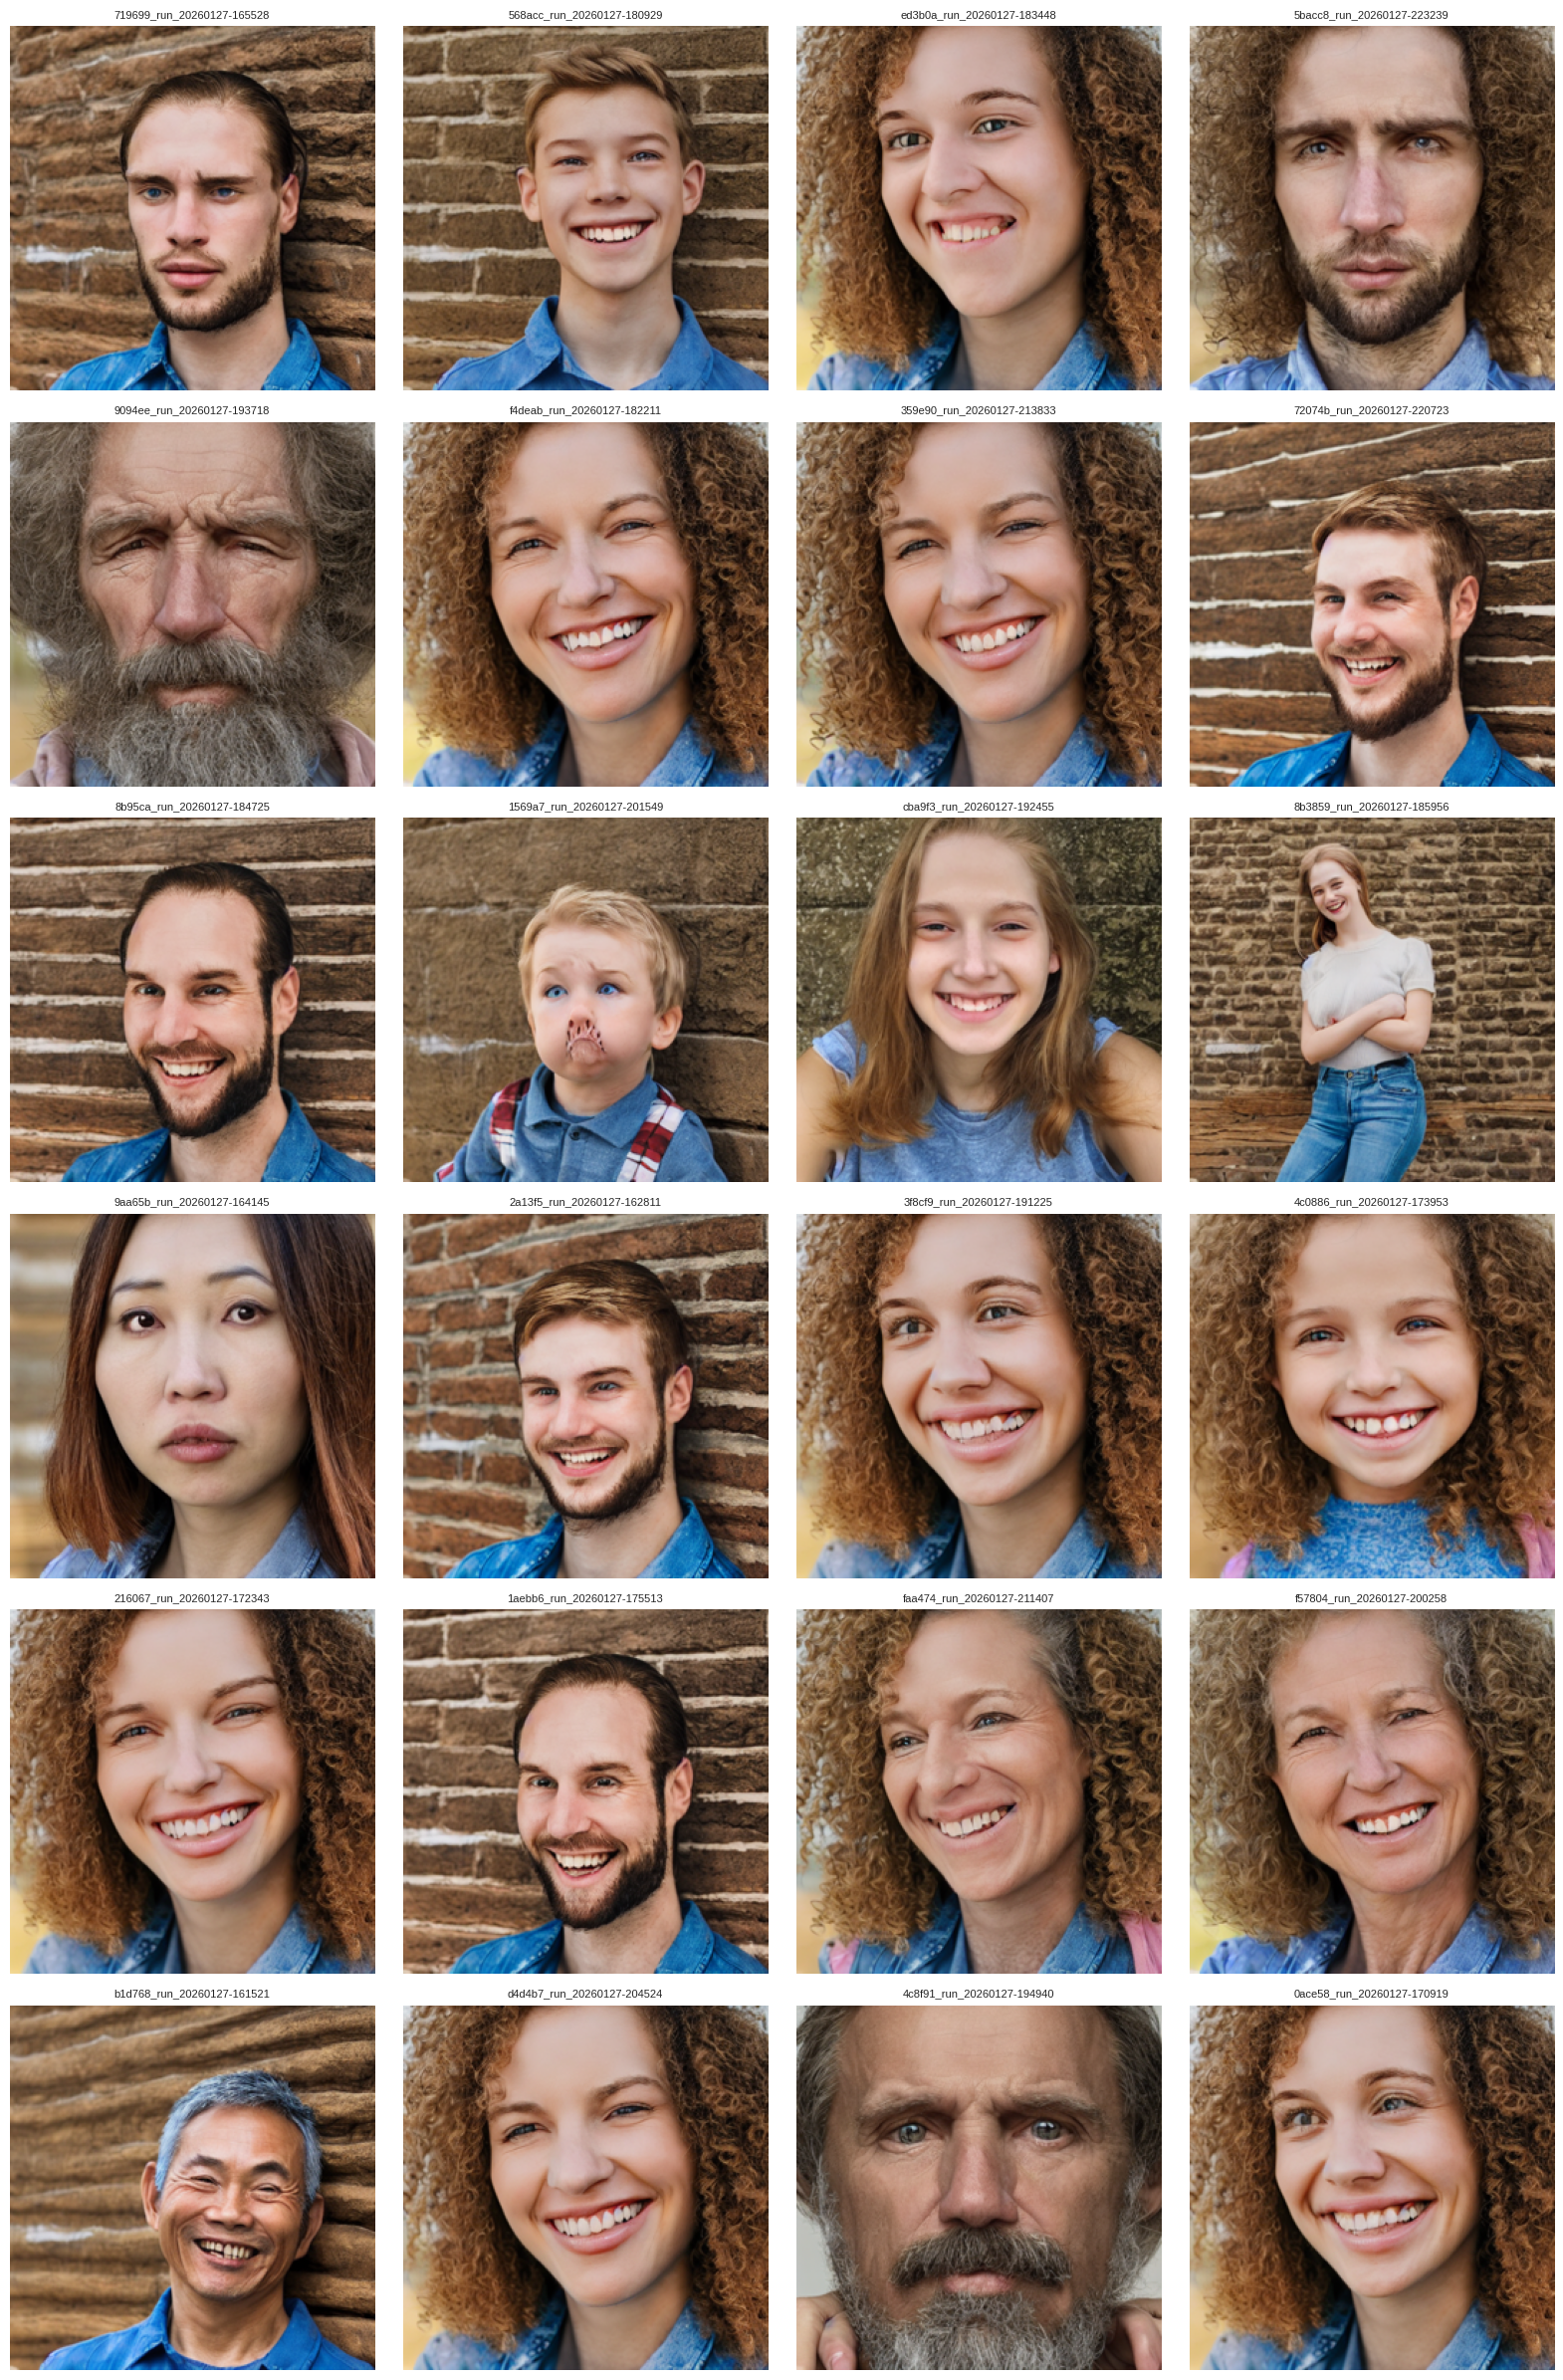

In [12]:
def load_image(path, size=(256, 256)):
    try:
        img = Image.open(path).convert("RGB")
        if size:
            img = img.resize(size)
        return img
    except Exception:
        return None

images = []
labels = []
for run_id, data in runs.items():
    epochs = data["history"].get("epochs", [])
    if not epochs:
        continue
    best, _ = best_epoch_row(epochs)
    img_path = best.get("sample_image_path") if best else None
    if not img_path:
        continue
    img = load_image(img_path, size=(256, 256))
    if img is None:
        continue
    images.append(img)
    labels.append(run_id)

if images:
    cols = min(4, len(images))
    rows = math.ceil(len(images) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 4*rows))
    if rows == 1 and cols == 1:
        axes = [axes]
    axes = np.array(axes).reshape(rows, cols)
    idx = 0
    for r in range(rows):
        for c in range(cols):
            ax = axes[r][c]
            ax.axis("off")
            if idx < len(images):
                ax.imshow(images[idx])
                ax.set_title(labels[idx], fontsize=8)
                idx += 1
    plt.tight_layout()
else:
    print("No sample images found in training history.")


## Notes
- AMP scaler stats are not logged yet (can be added if desired).
- Fixed prompt grids are not yet part of training; current samples are random prompts per epoch.
